# Superdense Coding
Superdense coding is a quantum communication protocol that allows for the transmission of two classical bits of information using only one qubit.

In [5]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit import ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator

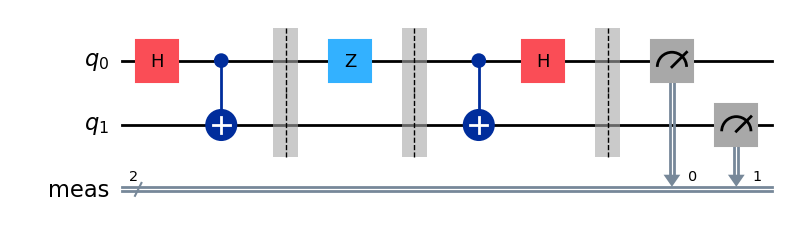

In [6]:
# note that b and a look out of order here, but trying to follow the diagram in the video
# https://www.youtube.com/watch?v=GSsElSQgMbU&list=PLOFEBzvs-VvqKKMXX4vbi4EB1uaErFMSO
# so the top (right) bit is b and the bottom (left) bit is a
b = '1'
a = '0'

phi_plus_entanglement_circuit = QuantumCircuit(2)
phi_plus_entanglement_circuit.h(0)
phi_plus_entanglement_circuit.cx(control_qubit=0, target_qubit=1)

superdense_coding = phi_plus_entanglement_circuit.copy()
superdense_coding.barrier()

if b == '1':
    superdense_coding.z(0)
if a == '1':
    superdense_coding.x(0)
superdense_coding.barrier()

superdense_coding.cx(control_qubit=0, target_qubit=1)
superdense_coding.h(0)
superdense_coding.measure_all()

display(superdense_coding.draw(output="mpl"))

Measured 01 with frequency 1024


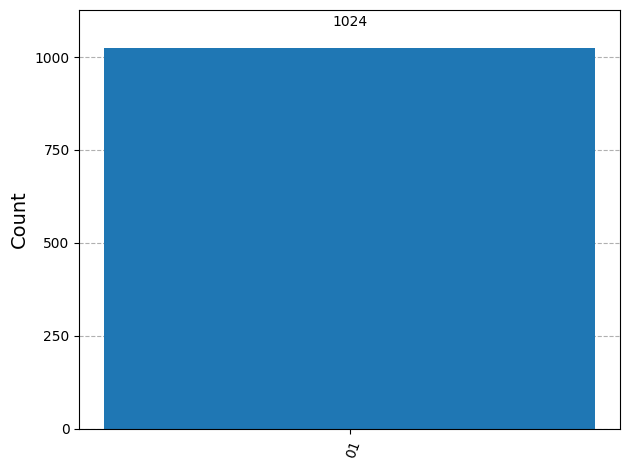

In [7]:
result = AerSimulator().run(superdense_coding).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

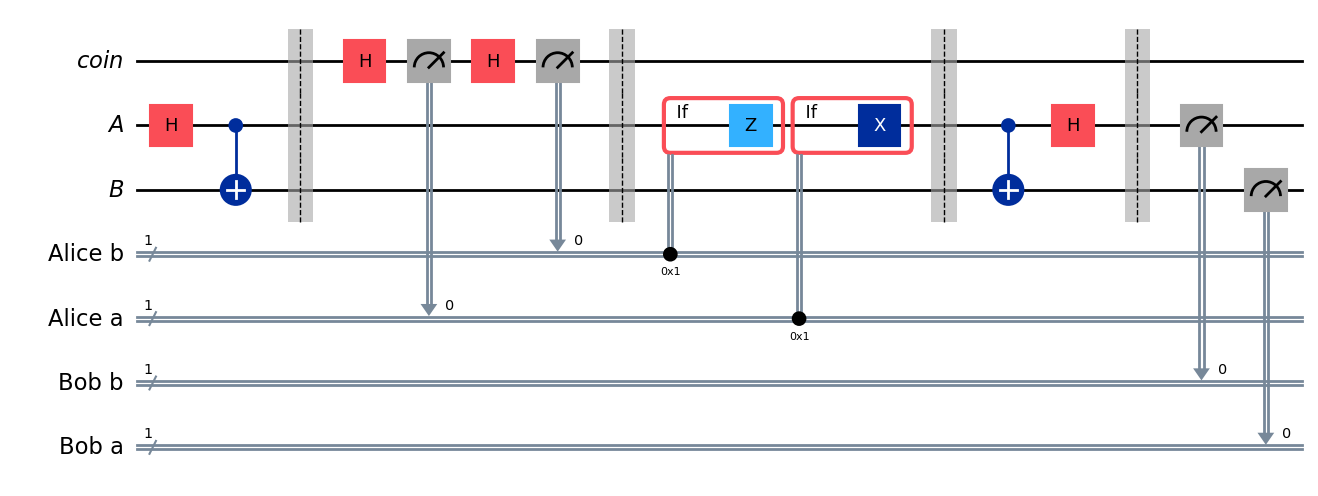

In [8]:
# now we'll show for every possible combo of a and b, we can recover the original message
ebit0 = QuantumRegister(1, 'A')
ebit1 = QuantumRegister(1, 'B')

rbg = QuantumRegister(1, 'coin')

# sender bits
Alice_b = ClassicalRegister(1, "Alice b")
Alice_a = ClassicalRegister(1, "Alice a")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_b, Alice_a)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# hadamard on the coin qubit to create a 50/50 superposition between ket1 and ket0
test.h(rbg)
test.measure(rbg, Alice_a)
test.h(rbg)
test.measure(rbg, Alice_b)
test.barrier()

# now run the protocol
with test.if_test((Alice_b, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_a, 1), label="X"):
    test.x(ebit0)
test.barrier()

test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()


# now receiver takes over
Bob_b = ClassicalRegister(1, "Bob b")
Bob_a = ClassicalRegister(1, "Bob a")
test.add_register(Bob_b)
test.add_register(Bob_a)
test.measure(ebit0, Bob_b)
test.measure(ebit1, Bob_a)

display(test.draw(output="mpl"))

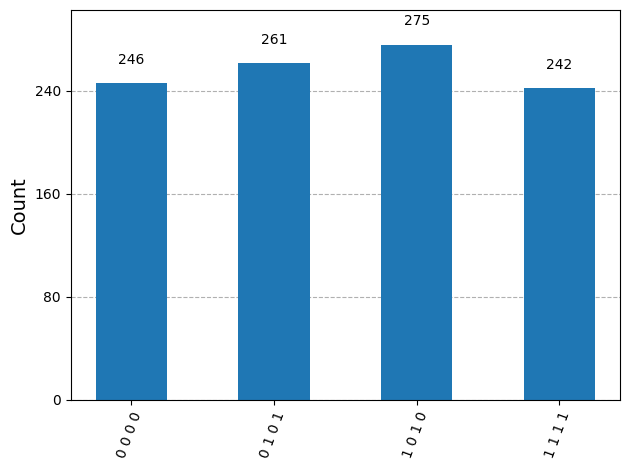

In [10]:
# run the simulation 
# notice that the first two bits (input) are always the same as the last two bits (output)
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))